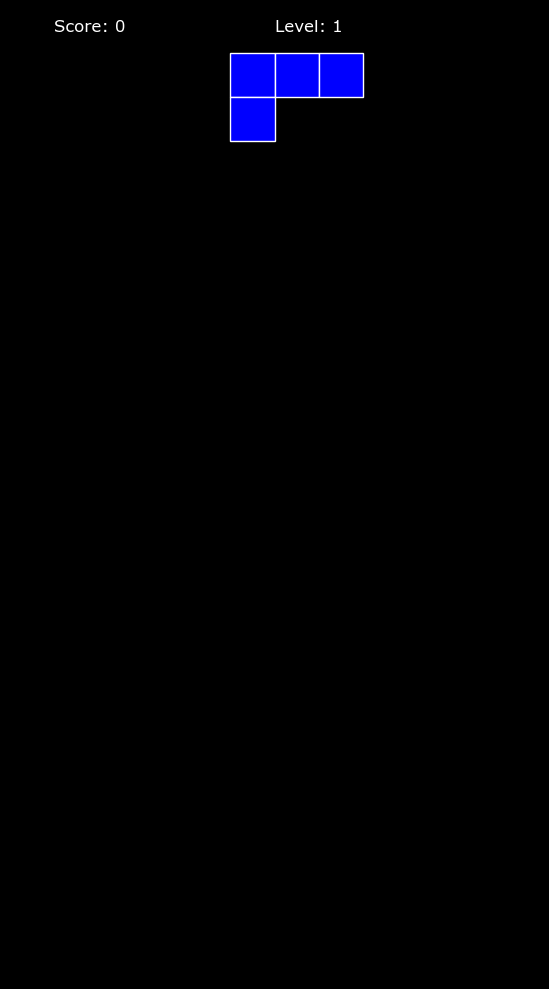

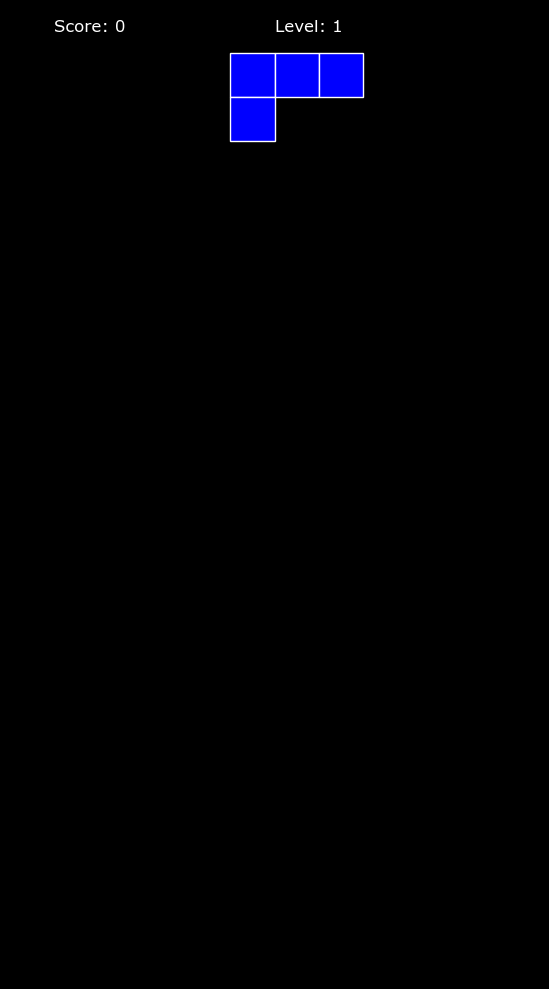

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.animation as animation
from IPython.display import display, clear_output
import ipywidgets as widgets
import time

# Tetris game implementation
class Tetris:
    def __init__(self, width=10, height=20):
        self.width = width
        self.height = height
        self.board = np.zeros((height, width), dtype=int)
        self.score = 0
        self.level = 1
        self.lines_cleared = 0
        self.game_over = False
        self.paused = False
        
        # Tetromino shapes and colors
        self.shapes = [
            [[1, 1, 1, 1]],  # I
            [[1, 1], [1, 1]],  # O
            [[1, 1, 1], [0, 1, 0]],  # T
            [[1, 1, 1], [1, 0, 0]],  # J
            [[1, 1, 1], [0, 0, 1]],  # L
            [[0, 1, 1], [1, 1, 0]],  # S
            [[1, 1, 0], [0, 1, 1]]   # Z
        ]
        
        self.colors = [
            'cyan',    # I
            'yellow',  # O
            'purple',  # T
            'blue',    # J
            'orange',  # L
            'green',   # S
            'red'      # Z
        ]
        
        self.current_piece = None
        self.current_color = None
        self.current_x = 0
        self.current_y = 0
        
        self.new_piece()
        
    def new_piece(self):
        # Select a random piece
        shape_idx = np.random.randint(len(self.shapes))
        self.current_piece = np.array(self.shapes[shape_idx])
        self.current_color = self.colors[shape_idx]
        
        # Start position (centered at top)
        self.current_x = self.width // 2 - len(self.current_piece[0]) // 2
        self.current_y = 0
        
        # Check if game is over (new piece can't be placed)
        if self.check_collision():
            self.game_over = True
    
    def check_collision(self):
        for y in range(len(self.current_piece)):
            for x in range(len(self.current_piece[0])):
                if self.current_piece[y][x]:
                    board_x = self.current_x + x
                    board_y = self.current_y + y
                    
                    # Check if out of bounds or overlapping with existing blocks
                    if (board_x < 0 or board_x >= self.width or 
                        board_y >= self.height or 
                        (board_y >= 0 and self.board[board_y][board_x])):
                        return True
        return False
    
    def merge_piece(self):
        for y in range(len(self.current_piece)):
            for x in range(len(self.current_piece[0])):
                if self.current_piece[y][x]:
                    board_x = self.current_x + x
                    board_y = self.current_y + y
                    if 0 <= board_y < self.height and 0 <= board_x < self.width:
                        self.board[board_y][board_x] = self.colors.index(self.current_color) + 1
    
    def rotate_piece(self):
        # Create a rotated version of the current piece
        rotated = np.rot90(self.current_piece)
        
        # Save original piece in case rotation causes collision
        original_piece = self.current_piece.copy()
        self.current_piece = rotated
        
        # If rotation causes collision, revert to original piece
        if self.check_collision():
            self.current_piece = original_piece
    
    def move(self, dx, dy):
        self.current_x += dx
        self.current_y += dy
        
        # If movement causes collision, revert it
        if self.check_collision():
            self.current_x -= dx
            self.current_y -= dy
            
            # If moving down caused collision, merge the piece and create a new one
            if dy > 0:
                self.merge_piece()
                self.clear_lines()
                self.new_piece()
                
                # Add score for placing a piece
                self.score += 10
    
    def drop(self):
        # Move the piece down until it collides
        while not self.check_collision():
            self.current_y += 1
        self.current_y -= 1  # Move back up one step
        self.merge_piece()
        self.clear_lines()
        self.new_piece()
        
        # Add score for dropping
        self.score += 20
    
    def clear_lines(self):
        lines_to_clear = []
        for y in range(self.height):
            if all(self.board[y]):
                lines_to_clear.append(y)
        
        # Remove the lines and add new empty ones at the top
        for line in lines_to_clear:
            self.board = np.delete(self.board, line, axis=0)
            self.board = np.vstack([np.zeros(self.width, dtype=int), self.board])
        
        # Update score and level
        if lines_to_clear:
            self.lines_cleared += len(lines_to_clear)
            self.score += [100, 300, 500, 800][min(len(lines_to_clear)-1, 3)] * self.level
            self.level = self.lines_cleared // 10 + 1
    
    def draw_board(self, ax):
        ax.clear()
        ax.set_xlim(-1, self.width + 1)
        ax.set_ylim(-1, self.height + 1)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_facecolor('black')
        
        # Draw the board
        for y in range(self.height):
            for x in range(self.width):
                if self.board[y][x]:
                    color_idx = self.board[y][x] - 1
                    rect = Rectangle((x, self.height - y - 1), 1, 1, 
                                    facecolor=self.colors[color_idx], edgecolor='white')
                    ax.add_patch(rect)
        
        # Draw the current piece
        if not self.game_over:
            for y in range(len(self.current_piece)):
                for x in range(len(self.current_piece[0])):
                    if self.current_piece[y][x]:
                        rect = Rectangle((self.current_x + x, self.height - (self.current_y + y) - 1), 
                                        1, 1, facecolor=self.current_color, edgecolor='white')
                        ax.add_patch(rect)
        
        # Draw the score and level
        ax.text(0, self.height + 0.5, f'Score: {self.score}', color='white', fontsize=12)
        ax.text(self.width - 5, self.height + 0.5, f'Level: {self.level}', color='white', fontsize=12)
        
        # Draw game over message if applicable
        if self.game_over:
            ax.text(self.width / 2 - 2, self.height / 2, 'GAME OVER', 
                   color='red', fontsize=20, fontweight='bold')
        
        # Draw pause message if applicable
        if self.paused:
            ax.text(self.width / 2 - 2, self.height / 2, 'PAUSED', 
                   color='yellow', fontsize=20, fontweight='bold')

# Create the game instance
tetris = Tetris()

# Create the figure and axis for the game
fig, ax = plt.subplots(figsize=(6, 10))
fig.patch.set_facecolor('black')

# Function to update the game display
def update_display():
    ax.clear()
    tetris.draw_board(ax)
    plt.tight_layout()
    clear_output(wait=True)
    display(fig)

# Function to handle keyboard events
def on_key(event):
    if tetris.game_over or tetris.paused:
        return
    
    if event.key == 'left':
        tetris.move(-1, 0)
    elif event.key == 'right':
        tetris.move(1, 0)
    elif event.key == 'down':
        tetris.move(0, 1)
    elif event.key == 'up':
        tetris.rotate_piece()
    elif event.key == ' ':
        tetris.drop()
    
    update_display()

# Connect the keyboard event
fig.canvas.mpl_connect('key_press_event', on_key)

# Create control buttons
button_layout = widgets.Layout(width='100px', height='40px')

left_button = widgets.Button(description='←', layout=button_layout)
right_button = widgets.Button(description='→', layout=button_layout)
down_button = widgets.Button(description='↓', layout=button_layout)
rotate_button = widgets.Button(description='↻', layout=button_layout)
drop_button = widgets.Button(description='Drop', layout=button_layout)
pause_button = widgets.Button(description='Pause', layout=button_layout)
restart_button = widgets.Button(description='Restart', layout=button_layout)

# Button event handlers
def on_left_button_clicked(b):
    if not tetris.game_over and not tetris.paused:
        tetris.move(-1, 0)
        update_display()

def on_right_button_clicked(b):
    if not tetris.game_over and not tetris.paused:
        tetris.move(1, 0)
        update_display()

def on_down_button_clicked(b):
    if not tetris.game_over and not tetris.paused:
        tetris.move(0, 1)
        update_display()

def on_rotate_button_clicked(b):
    if not tetris.game_over and not tetris.paused:
        tetris.rotate_piece()
        update_display()

def on_drop_button_clicked(b):
    if not tetris.game_over and not tetris.paused:
        tetris.drop()
        update_display()

def on_pause_button_clicked(b):
    tetris.paused = not tetris.paused
    update_display()

def on_restart_button_clicked(b):
    global tetris
    tetris = Tetris()
    update_display()

# Connect buttons to their handlers
left_button.on_click(on_left_button_clicked)
right_button.on_click(on_right_button_clicked)
down_button.on_click(on_down_button_clicked)
rotate_button.on_click(on_rotate_button_clicked)
drop_button.on_click(on_drop_button_clicked)
pause_button.on_click(on_pause_button_clicked)
restart_button.on_click(on_restart_button_clicked)

# Arrange buttons in a layout
button_box1 = widgets.HBox([left_button, down_button, right_button])
button_box2 = widgets.HBox([rotate_button, drop_button])
button_box3 = widgets.HBox([pause_button, restart_button])

controls = widgets.VBox([button_box1, button_box2, button_box3])

# Display the game and controls
print("Tetris Game - Use arrow keys to move, up to rotate, space to drop")
print("Or use the buttons below to control the game")
update_display()
display(controls)

# Auto-drop function
def auto_drop():
    while True:
        if not tetris.game_over and not tetris.paused:
            tetris.move(0, 1)
            update_display()
        time.sleep(max(0.5 - (tetris.level - 1) * 0.05, 0.1))  # Speed increases with level

# Uncomment the following line to enable auto-drop (might cause issues in some environments)
# import threading
# drop_thread = threading.Thread(target=auto_drop, daemon=True)
# drop_thread.start()